#### Goal:
This notebook establishes baseline regression models for predicting house price prediction. The objectives are to:
- Evaluate accuracy of point predictions
- Analyze residual patterns to assess model assumptions
- Provide a foundational referrence for subsequent uncertainty modeling.

### Imports

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [ ]:
df = pd.read_csv('C:/Users/Pratik/DS/house_prediction_uncertainty/data/processed/house_prices_features_v1.csv')

### Data Overview (Sanity Check)

Examining dataset's structure, shape & missing values to ensure data integrity.

In [3]:
df.shape # Checking the shape of the dataframe

(1460, 86)

In [4]:
df.isnull().sum() # Checking null counts

Id                0
MSSubClass        0
MSZoning          0
LotFrontage       0
LotArea           0
                 ..
SalePrice_log     0
TotalSF           0
HouseAge          0
RemodAge          0
TotalBathrooms    0
Length: 86, dtype: int64

### Target Distribution (Sanity Check)

Verifying the log-transformed target variable to ensure values are reasonable.

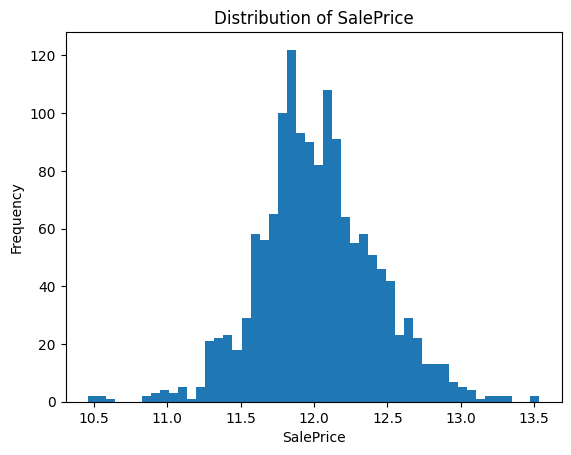

In [5]:
# Target distribution just to check the skewness
plt.hist(df['SalePrice_log'], bins=50)
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.title('Distribution of SalePrice')
plt.savefig('C:/Users/Pratik/DS/house_prediction_uncertainty/reports/figures/target_distribution_check.png')
plt.show()

### Data Splitting & Model Training

- The dataset was divided into training and testing subsets using a train–test split to evaluate model generalization. A fixed random state was used to ensure reproducibility.
- A linear regression model was selected as the baseline due to its interpretability and effectiveness for capturing linear relationships between features and the target variable.
- The linear regression model was fitted on the training data by learning the optimal coefficients that minimize the residual sum of squares between the observed and predicted target values.

In [6]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['SalePrice', 'SalePrice_log'])
y = df['SalePrice_log']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Using linear regression for baseline model 
from sklearn.linear_model import LinearRegression
model_LR = LinearRegression()
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)

The model generated predictions on the test set in the log-transformed target space. To interpret results in the original scale, an inverse log transformation was applied to both the predicted values and the true test targets, yielding y_pred_actual and y_test_actual, respectively.

In [8]:
# Inverse transform the log predictions to get actual sale prices
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

Model performance was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), computed on the test set in the original target scale. MAE provides a measure of average absolute prediction error, while RMSE penalizes larger errors more heavily, making it sensitive to outliers.

In [9]:
# Calculate RMSE & MAE on actual sale prices
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
print(f'RMSE: {rmse}, MAE: {mae}')

RMSE: 27665.513128951545, MAE: 18008.75857185007


The noticeably higher RMSE compared to the MAE indicates the presence of large error outliers. This is further corroborated by the variance, which shows that a small number of large errors are disproportionately influencing the overall error magnitude.

### Residual Analysis

The residuals were computed as the difference between the true target values and the model predictions:

Residual = y_true − y_pred

A histogram of the residuals was plotted with an overlaid kernel density estimate (KDE) to examine their distribution. This visualization helps assess key assumptions such as symmetry, normality, and the presence of outliers in the model errors.

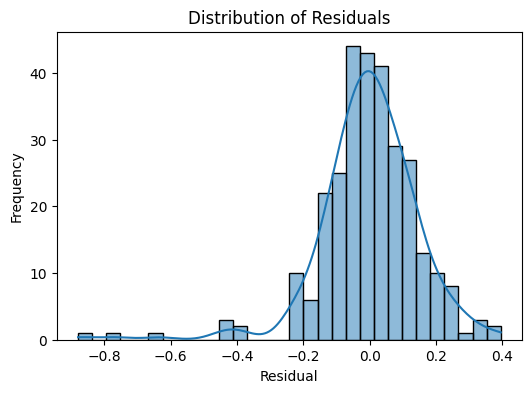

In [12]:
# Residual analysis
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.savefig('C:/Users/Pratik/DS/house_prediction_uncertainty/reports/figures/distribution_residuals.png')
plt.show()


The residuals are centered near zero, indicating minimal overall bias. However, mild skewness and the presence of extreme values are observed, suggesting occasional large prediction errors. This supports the discrepancy between RMSE and MAE, where RMSE is inflated by a small number of high-magnitude errors.

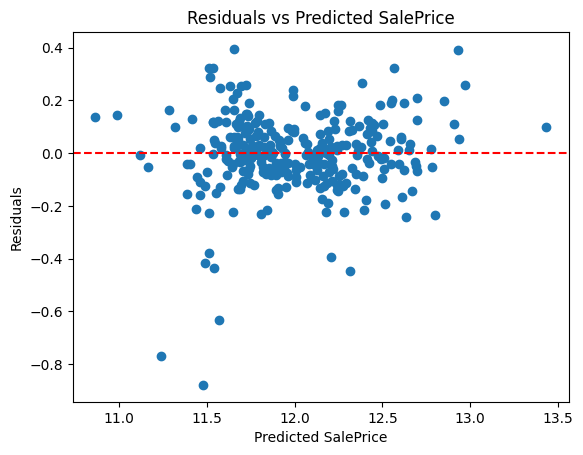

In [13]:
# Residual vs Predicted plot
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted SalePrice')
plt.savefig('C:/Users/Pratik/DS/house_prediction_uncertainty/reports/figures/residuals_vs_predicted_saleprice.png')
plt.show()

The residuals are centered around zero, indicating no strong bias. However, the spread of residuals increases for higher predicted prices, suggesting
heteroscedasticity.
The Linear regression provides a reasonable baseline, prediction uncertainty is not constant across price ranges, infering a need for uncertainty-aware models & prediction intervals.

### Regularization

Ridge regression was applied to reduce variance and improve the stability of house price predictions under uncertainty by penalizing large coefficients. Model performance was evaluated using MAE and RMSE on the test set for comparison with the baseline model.


In [14]:
# Regularization models like Ridge, Lasso can be tried next
from sklearn.linear_model import Ridge
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)
y_pred_ridge_actual = np.expm1(y_pred_ridge)

In [15]:
# Evaluate Ridge model
rmse_ridge = np.sqrt(mean_squared_error(y_test_actual, y_pred_ridge_actual))
mae_ridge = mean_absolute_error(y_test_actual, y_pred_ridge_actual)
print(f'Ridge RMSE: {rmse_ridge}, Ridge MAE: {mae_ridge}')

Ridge RMSE: 27690.096673224114, Ridge MAE: 17999.97560960248


When compared to the baseline linear regression model, Ridge regression exhibits a slightly higher RMSE but a marginally lower MAE. Given that limited hyperparameter tuning was performed, this suggests that regularization improves average prediction accuracy while still leaving room for further optimization to reduce large errors.

### XGBoost Model

XGBoost was used to model non-linear relationships and feature interactions in house price prediction. The model was trained on the same data split as previous models and evaluated using MAE and RMSE on the inverse-transformed target scale.


In [16]:
# XGBooost Regressor can be tried next
from xgboost import XGBRegressor
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
y_pred_xgb_actual = np.expm1(y_pred_xgb)

In [17]:
# Evaluate XGBoost model
rmse_xgb = np.sqrt(mean_squared_error(y_test_actual, y_pred_xgb_actual))
mae_xgb = mean_absolute_error(y_test_actual, y_pred_xgb_actual)
print(f'XGBoost RMSE: {rmse_xgb}, XGBoost MAE: {mae_xgb}')

XGBoost RMSE: 26388.0233208729, XGBoost MAE: 15941.041604238026


XGBoost model ocassionally overestimates prices by large margins, resulting in an RMSE comparable to other models. However, it's improved MAE indicates better average prediction accuracy and enhanced ability to capture complex patterns in data.

In [19]:
# Summary of model performances
model_summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'XGBoost Regressor'],
    'RMSE': [rmse, rmse_ridge, rmse_xgb],
    'MAE': [mae, mae_ridge, mae_xgb]
})
model_summary.to_csv('C:/Users/Pratik/DS/house_prediction_uncertainty/reports/summary _tables/model_summary.csv')
model_summary

,Model,RMSE,MAE
0,Linear Regression,27665.513129,18008.758572
1,Ridge Regression,27690.096673,17999.975610
2,XGBoost Regressor,26388.023321,15941.041604


The table summarizes the performance of the three models on the test set. XGBoost achieves the lowest RMSE and MAE, indicating superior predictive accuracy compared to Linear and Ridge Regression. While Ridge Regression slightly improves MAE over Linear Regression, it's RMSE remains similar. Overall, XGBoost demonstrates the best balance between minimizing average errors and controlling large deviations.

### Notes for Next Stage

- The baseline linear regression exhibits heteroscedastic residuals, with residual variance increasing as house prices rise.
- This indicates that prediction errors are not constant across price levels, violating homoscedasticity assumptions.
- Relying solely on point predictions is insufficient because they provide no information about the uncertainty or confidence around those estimates. In real estate pricing, understanding the range within which the true price may lie ie crucial for informed decision-making.

Next step: incorporate uncertainty quantification by applying quantile regression and evaluate the quality of prediction intervals through coverage metrics.